# **Phase 05 - XGBoost Prediction Model**
- More accurate than RandomForest
- Works well with less than 200K rows but not with millons of data

### **How the Model Learns**
- it don't use some coulumns such as : **company, symbol, date, dup_index, future_close_10d, future_return_10d, target_buy_10**
- Imagine training data like this
| volume_z | ret_5 | range_position | liquidity_rank | target |
|----------|-------|----------------|----------------|--------|
| 1.2      | 0.03  | 0.8            | 20             | 1      |
| -0.4     | -0.02 | 0.2            | 300            | 0      |
| 0.9      | 0.05  | 0.7            | 40             | 1      |

- The model tries to learn patterns like : (It learns statistical relationships.) <br>
*IF<br>
volume_z high
AND<br>
ret_5 positive<br>
AND<br>
range_position high<br>
THEN<br>
probability of profit increases*

### Create DuckDB Connection

In [1]:
import duckdb
import os

DB_FOLDER = "database"
DB_PATH = os.path.join(DB_FOLDER, "cse_data.db")

con = duckdb.connect(database=DB_PATH)

In [2]:
stock_features_labeled_10d_df = con.execute("""
    SELECT *
    FROM stocks_features_labeled_10d_table
""").fetch_df()

features = [
    # Momentum
    "ret_5", "ret_10", "ma_ratio_5", "ma_ratio_10", "momentum_score", "trend_angle",
    # Volatility
    "std_close_10", "std_close_20", "atr_14", "volatility_score", "range_5",
    # Liquidity
    "volume_ratio", "volume_z", "liquidity_rank", "avg_vol_20",
    # Relative/position
    "price_position", "range_position", "breakout_flag"
]

X = stock_features_labeled_10d_df[features]
y = stock_features_labeled_10d_df["target_buy_10d"]

In [5]:
# !pip install xgboost

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,      # number of trees
    learning_rate=0.05,    # step size shrinkage
    max_depth=5,           # tree depth
    subsample=0.8,         # fraction of data per tree
    colsample_bytree=0.8,  # fraction of features per tree
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)


# Predict probabilities
# here predict_proba rtuen [o.8, 0.2] such a array so [class 0, class 1] this is differ from predict() function, let conside only class 1 we need it
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]
print("============== \n", y_pred_proba)

# Adding new row for Top-K Backtest buy calculating probalilty of getting profit
# predict on all rows
# predict_proba() - returns two probabilities for each row > [ P(class 0), P(class 1) ] > [probability_of_0, probability_of_1]
# stock_features_labeled_10d_df["prob"] = y_pred_proba

# Create new table called stocks_10d_prob_table with prob column using df
con.execute("""
    CREATE OR REPLACE TABLE stocks_10d_prob_table AS
    SELECT * FROM stock_features_labeled_10d_df
""")

 [0.06997123 0.03646532 0.04798112 ... 0.06403986 0.06190309 0.07121582]


In [6]:
df = con.execute("SELECT * FROM stocks_10d_prob_table").fetch_df()
df.sample(5)

,company,symbol,volume,trades,prev_close,open,high,low,close,change,...,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d
4123,HATTON NATIONAL BANK PLC,HNB.N0000,127229,223,427.75,426.75,430.0,425.0,426.25,-1.50,...,0,-0.003261,5.238680,0.001753,1.734398,0.837209,106.0,455.0,0.067449,1
8744,RADIANT GEMS INTERNATIONAL PLC,RGEM.N0000,877,28,169.75,179.50,179.5,165.0,170.00,0.25,...,0,0.021045,12.094372,0.031927,-2.466541,0.322581,233.0,NaN,NaN,0
2889,SINGER (SRI LANKA) PLC,SINS.N0000,51777,125,84.00,84.60,84.8,83.5,83.60,-0.40,...,0,-0.032266,2.255201,0.002414,-0.945414,0.000000,135.0,62.1,-0.257177,0
9446,SERENDIB HOTELS PLC,SHOT.N0000,7683,18,21.90,21.90,21.9,20.7,21.80,-0.10,...,0,0.032567,0.698258,0.002343,-0.034812,0.941176,170.0,18.3,-0.160550,0
3418,LAUGFS POWER PLC,LPL.N0000,255626,175,11.00,11.50,12.7,11.5,12.10,1.10,...,0,0.035673,0.827342,0.000685,-0.126015,0.424242,132.0,NaN,NaN,0


### Evaluation

In [7]:
# Calculate ROC AUC
# Receiver Operating Characteristic – Area Under Curve
# How well your model separates Class 0 and Class 1
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC:", roc_auc,"\n")


from sklearn.metrics import accuracy_score, classification_report
preds = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, preds))

ROC AUC: 0.7108237424026898 

              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2035
           1       0.58      0.13      0.21       323

    accuracy                           0.87      2358
   macro avg       0.73      0.56      0.57      2358
weighted avg       0.84      0.87      0.83      2358



### ROC Graph

Blue curve → model
Red dashed line → random guessing (AUC = 0.5)
The closer the blue curve is to top-left, the better the model


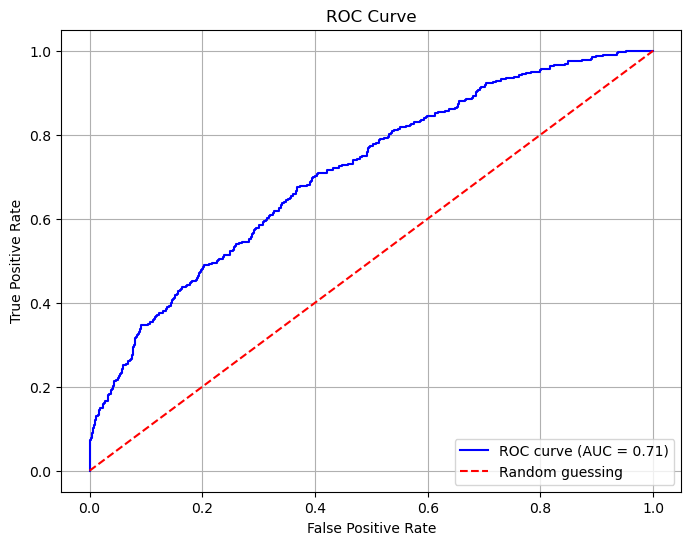

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test → true labels
# y_pred_proba → predicted probability for class 1 (BUY)
# fpr → False Positive Rate = FP / (FP + TN)
# tpr → True Positive Rate = TP / (TP + FN)
# thresholds → probability thresholds used    
fpr, tpr, thrsholds = roc_curve(y_test, y_pred_proba)

# Compute area under curve
roc_auc = auc(fpr, tpr)

print("Blue curve → model")
print("Red dashed line → random guessing (AUC = 0.5)")
print("The closer the blue curve is to top-left, the better the model")

# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### XGB Model Evaluation

In [9]:
stock_features_labeled_10d_df.head()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,...,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d
0,ABANS ELECTRICALS PLC,ABAN.N0000,813,47,1201.50,1215.00,1255.00,1202.0,1247.25,45.75,...,0,-0.045714,92.578046,0.057811,-18.365038,0.116486,244.0,1300.75,0.042894,0
1,ABANS ELECTRICALS PLC,ABAN.N0000,7959,276,1247.25,1254.00,1550.00,1245.0,1393.00,145.75,...,0,0.056660,99.845589,0.034678,-18.771805,0.487588,251.0,1297.00,-0.068916,0
2,ABANS ELECTRICALS PLC,ABAN.N0000,10714,72,1393.00,1390.00,1420.00,1390.0,1400.00,7.00,...,0,0.017430,107.925534,0.006720,-17.821992,0.505411,251.0,1280.25,-0.085536,0
3,ABANS ELECTRICALS PLC,ABAN.N0000,578,51,1396.50,1390.00,1410.00,1370.0,1373.25,-23.25,...,0,0.010639,99.233277,0.088235,-17.015789,0.437301,251.0,1279.50,-0.068269,0
4,ABANS ELECTRICALS PLC,ABAN.N0000,425,53,1374.00,1398.75,1398.75,1350.0,1351.25,-22.75,...,0,0.010362,78.968160,0.124706,-16.675752,0.381286,255.0,1237.50,-0.084181,0


In [10]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
""").fetch_df()

print(tables)

                           table_name
0                    raw_stocks_table
1               stocks_10d_prob_table
2                  stocks_clean_table
3         stocks_features_clean_table
4   stocks_features_labeled_10d_table
5               stocks_features_table
6                 stocks_sorted_table
7                        stocks_table
8             temp_future_price_table
9                temp_liquidity_table
10                 temp_returns_table
11                   temp_trend_table
12                      temp_tr_table
13                     temp_vol_table


### Close DuckDB Connection

In [11]:
if 'con' in globals():  # Check if connection exists
    try:
        con.close()        # Close it
        print("DuckDB connection closed.")
    except Exception as e:
        print("Error closing DuckDB:", e)
    finally:
        del con             # Delete the variable from memory

DuckDB connection closed.
